In [249]:
import pandas as pd
from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED
from cdc_ml.features.build_features import assign_class_type
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [250]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)
df = assign_class_type(df,df_class)

In [251]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32634 entries, 0 to 32633
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 32634 non-null  int64                         
 1   username           32634 non-null  str                           
 2   cycle_start        32634 non-null  datetime64[ns, Asia/Singapore]
 3   cycle_end          32634 non-null  datetime64[ns, Asia/Singapore]
 4   polling_at         32634 non-null  datetime64[ns, Asia/Singapore]
 5   booking_hour       538 non-null    datetime64[ns, Asia/Singapore]
 6   has_booking        32634 non-null  bool                          
 7   cycle_start_month  32634 non-null  int32                         
 8   cycle_start_day    32634 non-null  int32                         
 9   cycle_start_dow    32634 non-null  int32                         
 10  cycle_start_hour   32634 non-null  int32     

In [252]:
df.tail()

,id,username,cycle_start,cycle_end,polling_at,booking_hour,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
32629,32629,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 19:00:00+08:00,NaT,False,3,30,0,10,4,13,0,19,345.0,1,1
32630,32630,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 20:00:00+08:00,NaT,False,3,30,0,10,4,13,0,20,346.0,1,1
32631,32631,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 21:00:00+08:00,NaT,False,3,30,0,10,4,13,0,21,347.0,1,1
32632,32632,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 22:00:00+08:00,NaT,False,3,30,0,10,4,13,0,22,348.0,1,1
32633,32633,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 23:00:00+08:00,NaT,False,3,30,0,10,4,13,0,23,349.0,1,1


In [253]:
counts = df["has_booking"].value_counts()
shares = df["has_booking"].value_counts(normalize=True)

tp = pd.concat([counts, shares], axis=1)
tp.columns = ["count", "share"]

In [254]:
tp

,count,share
has_booking,,
False,32096,0.983514
True,538,0.016486


In [255]:
def eda_label_rate(x):
    label_rate = (
        df.groupby(x)["has_booking"]
        .agg(share="mean", count="count")
        .reset_index()
    )
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Top: label rate with 95% CI
    sns.barplot(data=df, x=x, y="has_booking", ax=axes[0], errorbar=("ci", 95))
    axes[0].set_ylabel("P(has_booking)")

    # Bottom: exposure per category
    sns.barplot(data=label_rate, x=x, y="count", ax=axes[1], color="steelblue")
    axes[1].set_ylabel("n observations")

    plt.tight_layout()


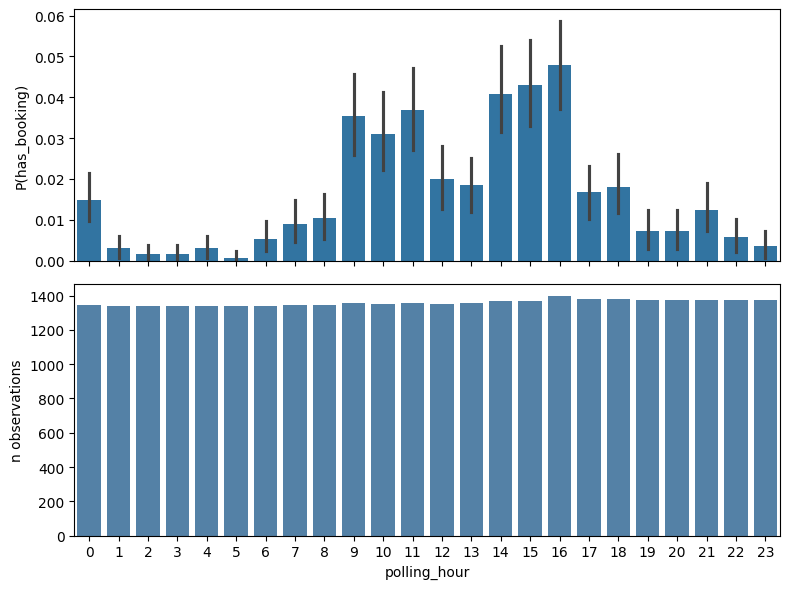

In [256]:
eda_label_rate("polling_hour")

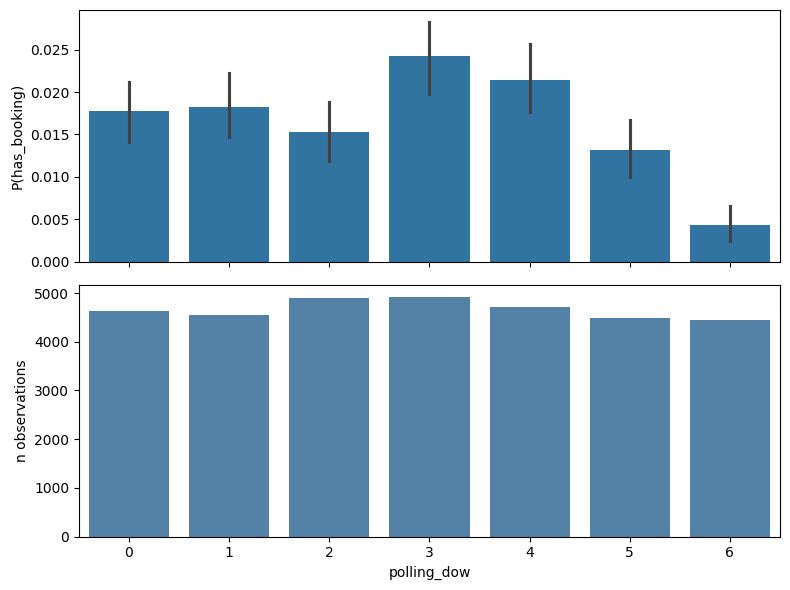

In [257]:
eda_label_rate("polling_dow")

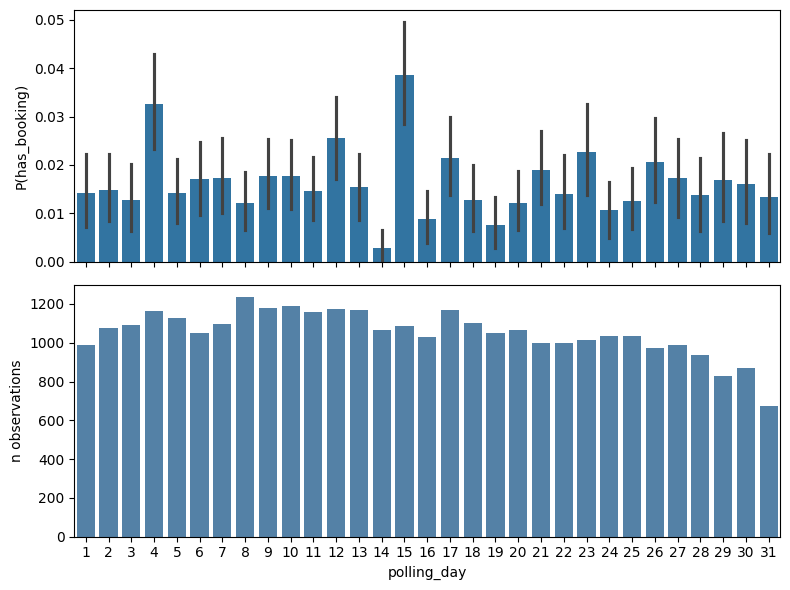

In [258]:
eda_label_rate("polling_day")

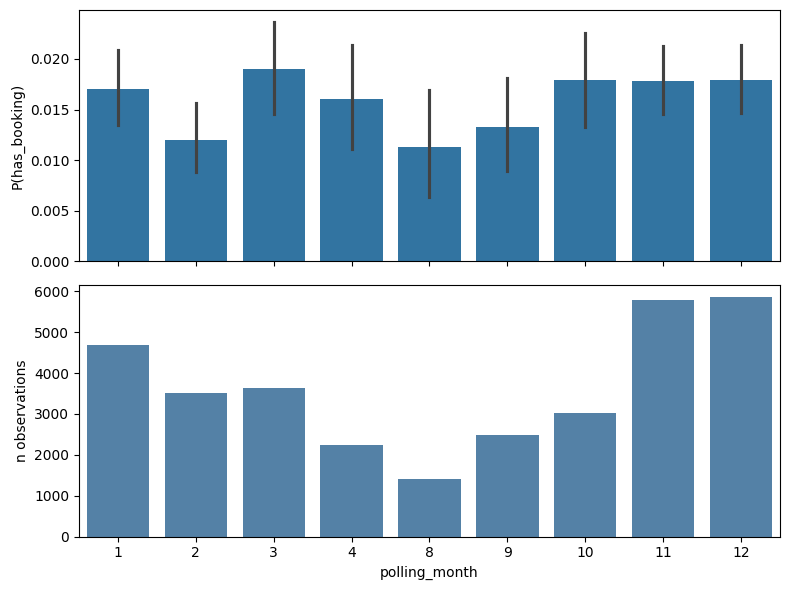

In [259]:
label_rate_by_polling_month = eda_label_rate("polling_month")

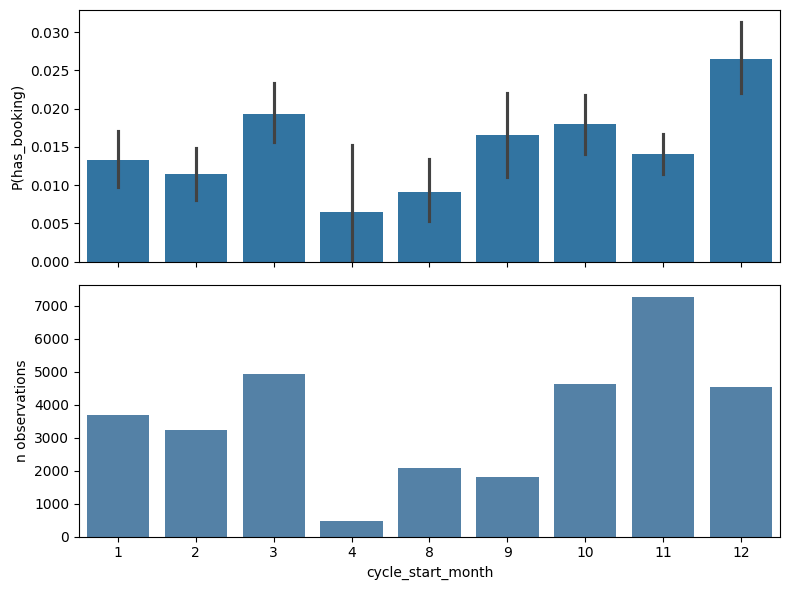

In [260]:
eda_label_rate("cycle_start_month")

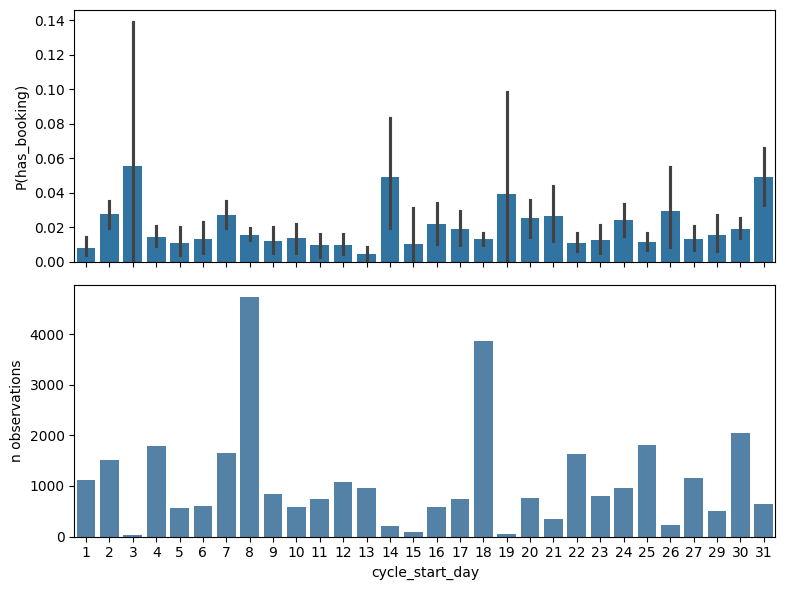

In [261]:
eda_label_rate("cycle_start_day")

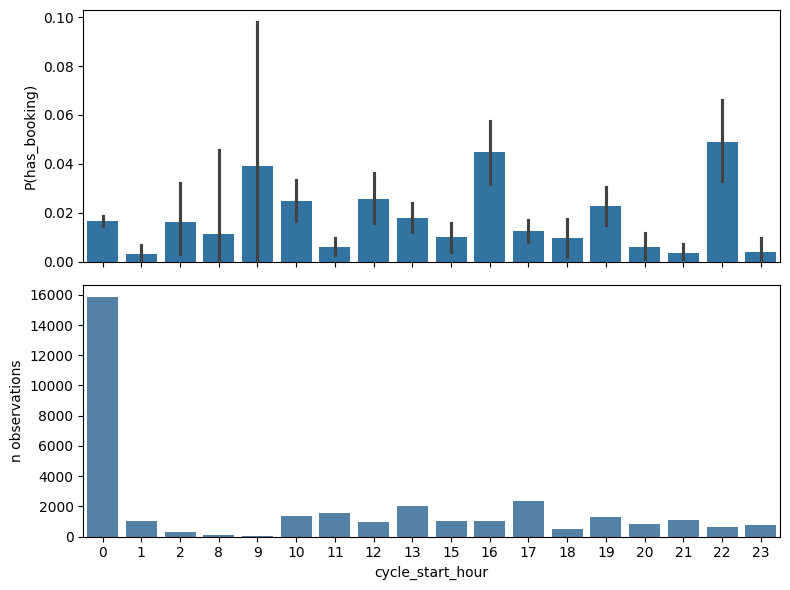

In [262]:
eda_label_rate("cycle_start_hour")

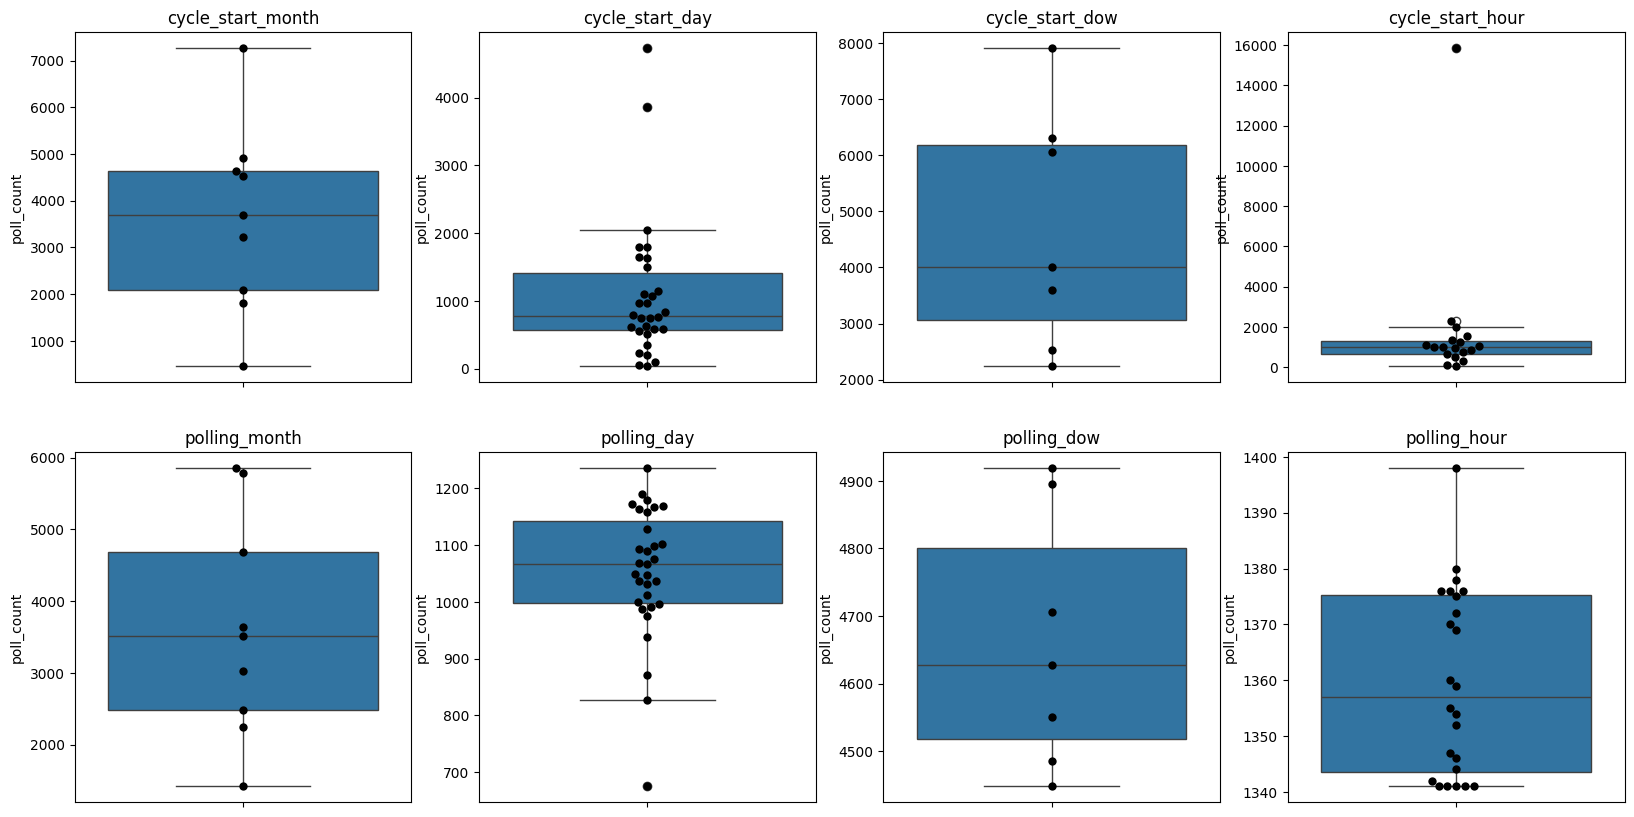

In [263]:
fig,axes = plt.subplots(2,4,figsize=(20,10))

plot_lists = [["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour",],
              ["polling_month","polling_day","polling_dow","polling_hour"]
              ]

for i in range(2):
    for j in range(4):
        current = plot_lists[i][j]
        count = df.groupby(current)["username"].count().reset_index(name="poll_count")
        sns.boxplot(y=count["poll_count"],ax=axes[i][j])
        sns.swarmplot(y=count["poll_count"], color="black", size=6,ax=axes[i][j])
        axes[i][j].set_title(current)  

In [264]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramer_v_table():
    df = pd.DataFrame({
        "dof":[1,2,3,4,5],
        "small":[.10,.07,.06,.05,.05],
        "medium":[.30,.21,.17,.15,.13],
        "large":[.50,.35,.29,.25,.22]
    })
    return df

def corr_check_chi_v(x,y):
    exact_match = (df[x] == df[y]).mean()
    print(f"Exact match rate: {exact_match:.1%}")

    ct = pd.crosstab(df[x], df[y])
    chi2, p, dof, _ = chi2_contingency(ct)

    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"χ²={chi2:.1f}, p={p:.2e}, Cramér's V={cramers_v:.3f} dof={min_dim} \n")
    print(cramer_v_table())




In [265]:
corr_check_chi_v("cycle_start_month","polling_month")

Exact match rate: 70.1%
χ²=148713.6, p=0.00e+00, Cramér's V=0.755 dof=8 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [266]:
corr_check_chi_v("cycle_start_day","polling_day")

Exact match rate: 6.6%
χ²=30657.3, p=0.00e+00, Cramér's V=0.180 dof=29 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [267]:
corr_check_chi_v("cycle_start_hour","polling_hour")

Exact match rate: 4.3%
χ²=25.2, p=1.00e+00, Cramér's V=0.007 dof=17 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [268]:

corr_check_chi_v("polling_month","polling_day")

Exact match rate: 3.8%
χ²=6420.0, p=0.00e+00, Cramér's V=0.157 dof=8 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [269]:
corr_check_chi_v("polling_day","polling_dow")

Exact match rate: 0.0%
χ²=13577.8, p=0.00e+00, Cramér's V=0.263 dof=6 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [270]:
corr_check_chi_v("polling_dow","polling_hour")

Exact match rate: 4.1%
χ²=4.9, p=1.00e+00, Cramér's V=0.005 dof=6 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [271]:
corr_check_chi_v("polling_dow","has_booking")

Exact match rate: 14.2%
χ²=70.9, p=2.66e-13, Cramér's V=0.047 dof=1 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [272]:

corr_check_chi_v("polling_hour","has_booking")

Exact match rate: 4.1%
χ²=424.8, p=1.38e-75, Cramér's V=0.114 dof=1 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


   username  has_booking
32     ryan         1967
33    anmol         2067
34   flower         2268
35       jy         2369
36      kim         3821


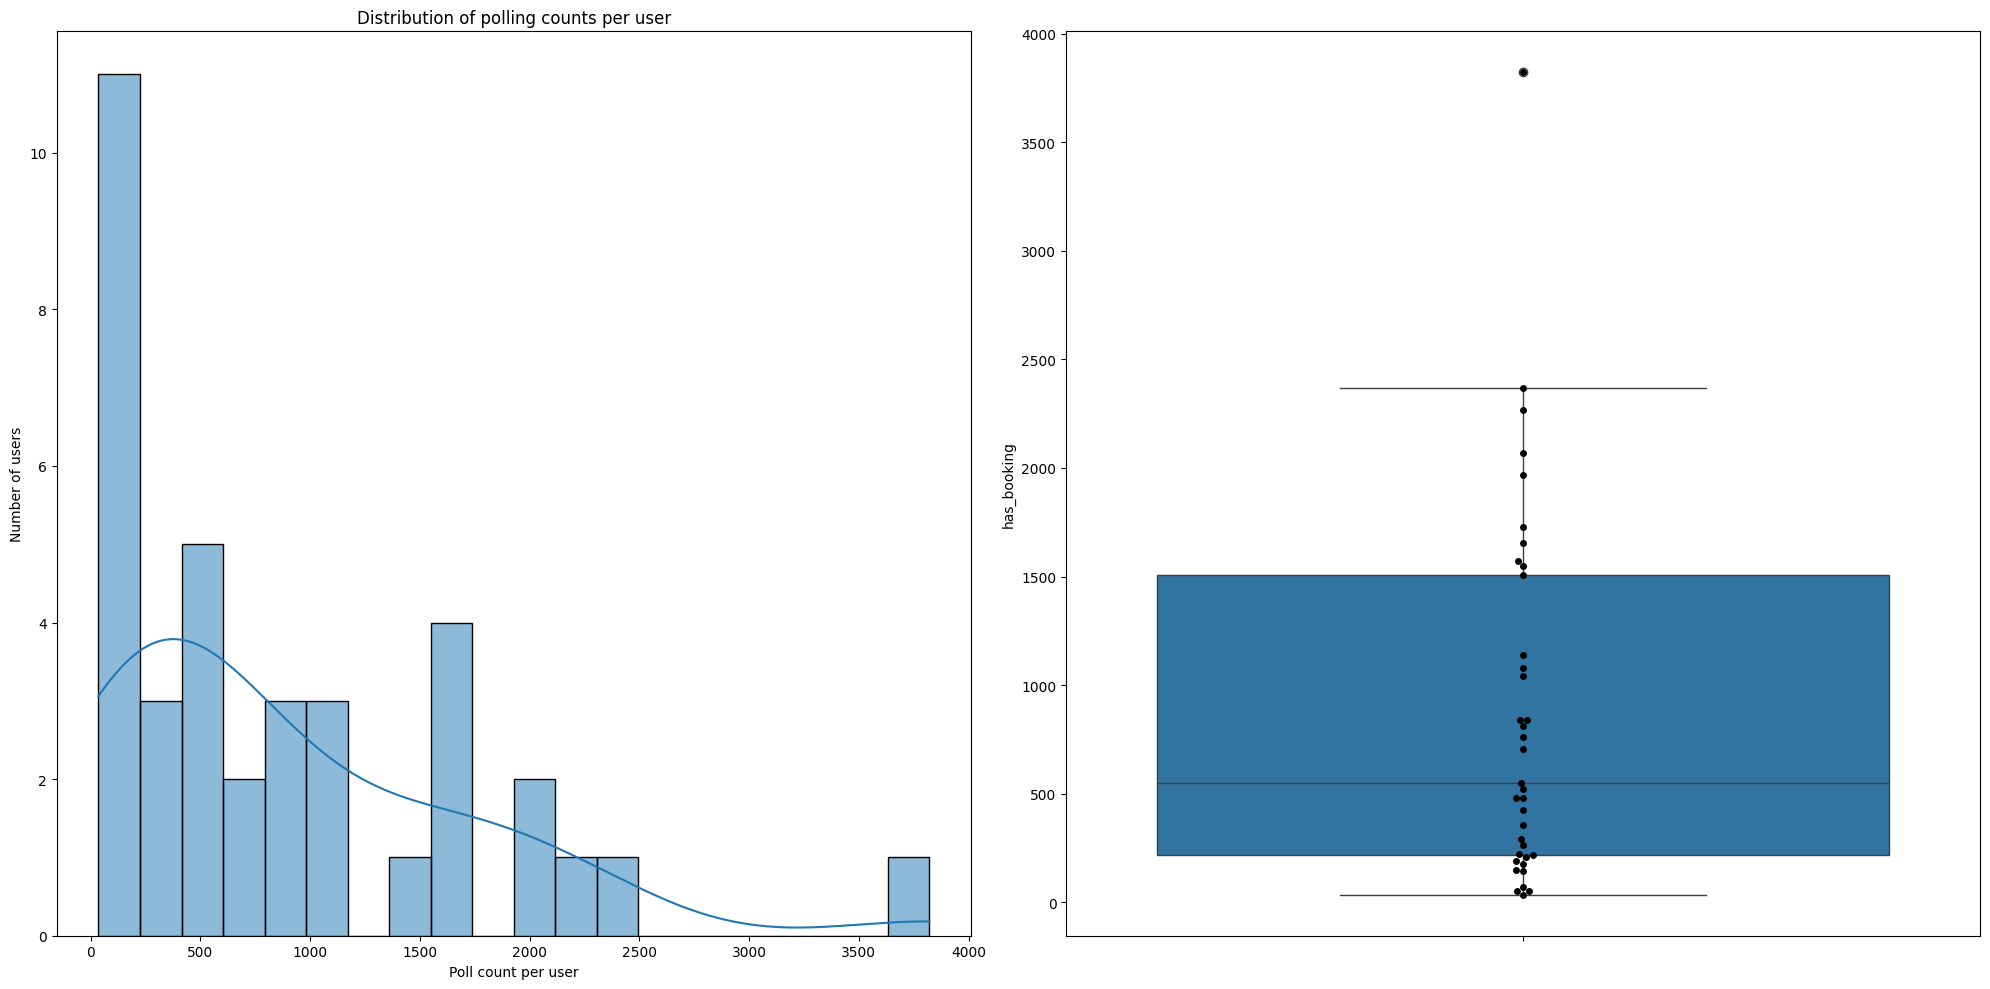

In [273]:
user_distribution = df.groupby("username")["has_booking"].count().sort_values().reset_index()
print(user_distribution.tail())

fig, axes = plt.subplots(1,2,figsize=(20, 10))
sns.histplot(
    data=user_distribution,
    x="has_booking",
    bins=20,
    kde=True,      
    ax=axes[0]
)
axes[0].set_xlabel("Poll count per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Distribution of polling counts per user")

sns.boxplot(data=user_distribution,y="has_booking",ax=axes[1])
sns.swarmplot(data=user_distribution,y="has_booking",color="black",ax=axes[1])
plt.tight_layout()
plt.show()

In [274]:
count = df.groupby(["username"])["has_booking"].count().reset_index()
q_25,q_50,q_75 = count["has_booking"].quantile([0.25,0.5,0.75])

iqr = q_75 - q_25
print(q_25,q_50,q_75,iqr)

217.0 552.0 1507.0 1290.0


<Axes: xlabel='poll_count', ylabel='booking_rate'>

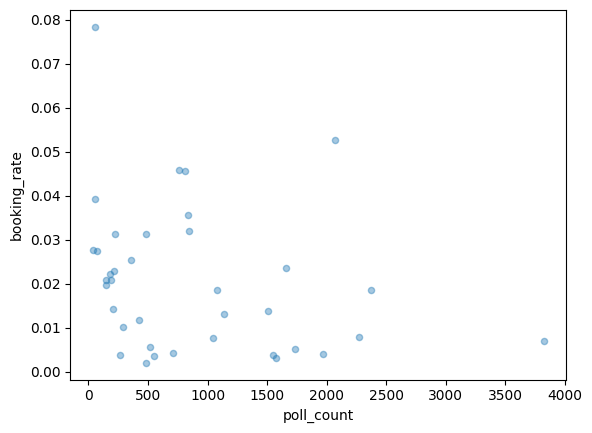

In [275]:
stats = df.groupby("username")["has_booking"].agg(["count", "mean"]).reset_index()
stats.columns = ["username", "poll_count", "booking_rate"]

# Does booking rate correlate with how long they've been observed?
stats.plot.scatter(x="poll_count", y="booking_rate", alpha=0.4)

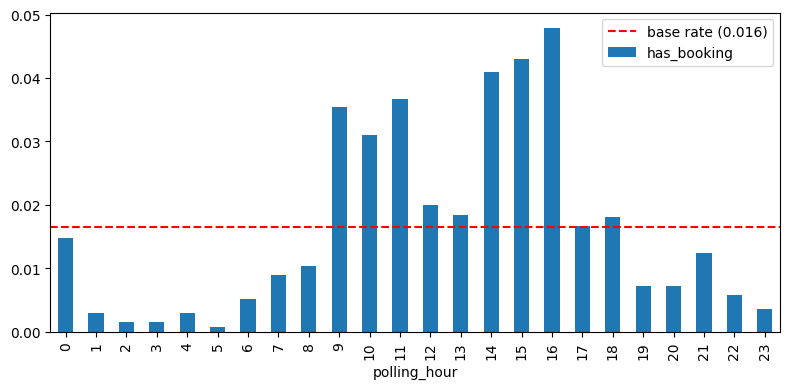

In [276]:
def success_share(x):
    rate = df.groupby(x)["has_booking"].mean()
    base = df["has_booking"].mean()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    rate.plot(kind="bar", ax=ax)
    ax.axhline(base, color="red", linestyle="--", label=f"base rate ({base:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.show()

success_share("polling_hour")


   username  count     share
0       kim   3821  0.117086
1        jy   2369  0.072593
2    flower   2268  0.069498
3     anmol   2067  0.063339
4      ryan   1967  0.060275
5     anaya   1730  0.053012
6       mya   1656  0.050745
7      matt   1574  0.048232
8       ali   1550  0.047496
9      srpr   1507  0.046179
10    faith   1141  0.034964
11   tomato   1079  0.033064
12  brendon   1044  0.031991
13      joy    842  0.025801
14      jun    840  0.025740
15    apple    812  0.024882
16   poopie    762  0.023350
17  gohguan    706  0.021634
18    natar    552  0.016915
19      fir    521  0.015965
20       bw    481  0.014739
21   addity    480  0.014709
22       np    425  0.013023
23    bryan    355  0.010878
24  lucinda    294  0.009009
25        d    264  0.008090
26   aswath    224  0.006864
27      nur    217  0.006650
28     phuc    209  0.006404
29    carol    192  0.005883
30     sara    179  0.005485
31  pakning    151  0.004627
32    bhara    144  0.004413
33    isyaf   

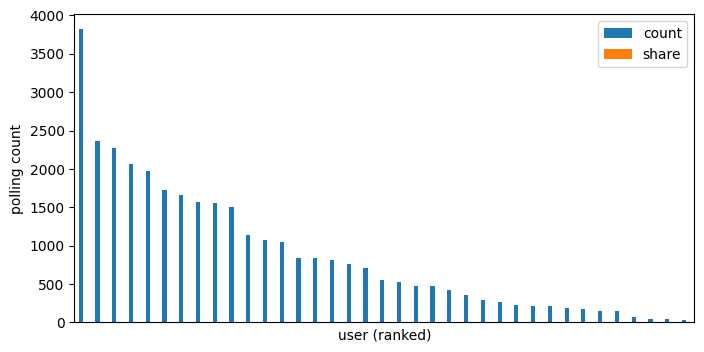

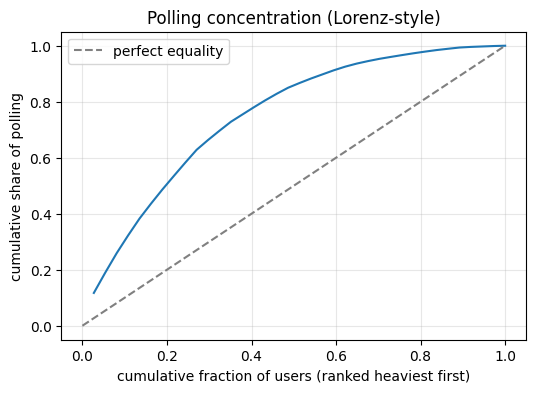

In [277]:
counts = df['username'].value_counts().reset_index().assign(share=lambda x:x["count"]/len(df))
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax)
ax.set_ylabel('polling count')
ax.set_xlabel('user (ranked)')
ax.set_xticks([])  # hide labels if there are many users


counts_sorted = (
    counts.sort_values('share', ascending=False)
          .reset_index(drop=True)
)
counts_sorted['cum_share'] = counts_sorted['share'].cumsum()
counts_sorted['cum_user_frac'] = (counts_sorted.index + 1) / len(counts_sorted)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(counts_sorted['cum_user_frac'], counts_sorted['cum_share'])
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share of polling')
ax.set_title('Polling concentration (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

for k in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(k * len(counts_sorted)))
    print(f'top {k:.0%} of users ({n}) → {counts_sorted["share"].head(n).sum():.1%} of polls')

In [278]:
import numpy as np

def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

print(f'Gini: {gini(counts["share"].values):.3f}')

Gini: 0.497


<Axes: xlabel='hours_into_cycle', ylabel='Count'>

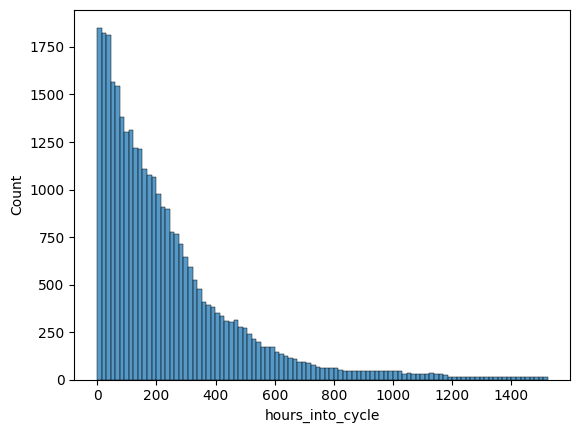

In [279]:
sns.histplot(data=df,x="hours_into_cycle")

    is_one_team             hours_bin  has_booking
0             0     (-2.474, 151.468]     0.016838
1             0    (151.468, 303.887]     0.021691
2             0    (303.887, 456.305]     0.016047
3             0    (456.305, 608.723]     0.029281
4             0    (608.723, 761.142]     0.010370
5             0     (761.142, 913.56]     0.023364
6             0    (913.56, 1065.978]     0.000000
7             0  (1065.978, 1218.397]     0.027273
8             1     (-2.474, 151.468]     0.019930
9             1    (151.468, 303.887]     0.006481
10            1    (303.887, 456.305]     0.007060
11            1    (456.305, 608.723]     0.007962
12            1    (608.723, 761.142]     0.000000
13            1     (761.142, 913.56]     0.000000
14            1    (913.56, 1065.978]     0.000000
15            1  (1065.978, 1218.397]     0.013072
16            1  (1218.397, 1370.815]     0.000000
17            1  (1370.815, 1523.233]     0.000000
    is_one_team             hou

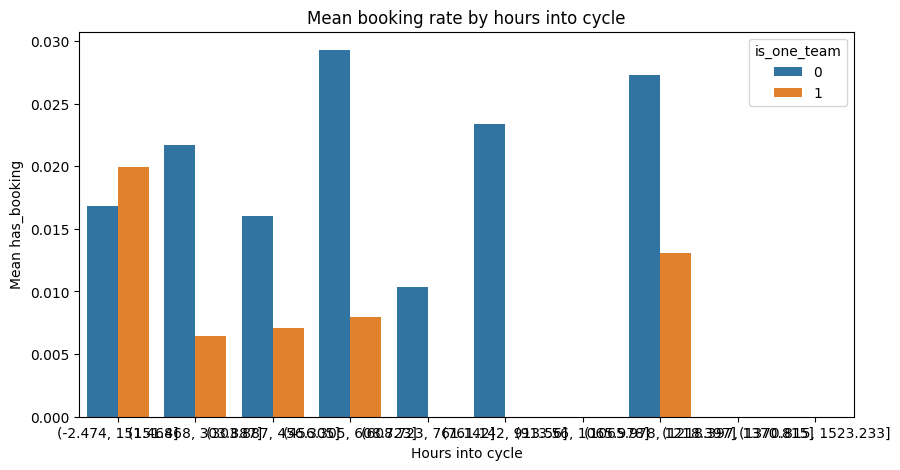

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_bin = pd.cut(df["hours_into_cycle"],bins=10)
df = df.assign(hours_bin=hour_bin)
hours_into_share = df.groupby(['is_one_team',"hours_bin"])["has_booking"].mean().reset_index()
print(hours_into_share)

print(hours_into_share)
plt.figure(figsize=(10,5))
sns.barplot(data=hours_into_share,x="hours_bin", y="has_booking",hue="is_one_team")
plt.xlabel("Hours into cycle")
plt.ylabel("Mean has_booking")
plt.title("Mean booking rate by hours into cycle")
plt.show()

In [281]:
one_team_count = df["is_one_team"].value_counts(normalize=True)
print(one_team_count)



is_one_team
0    0.681008
1    0.318992
Name: proportion, dtype: float64


In [282]:
team_count= df.groupby(["is_one_team"])["has_booking"].mean()
print(team_count)


is_one_team
0    0.018808
1    0.011527
Name: has_booking, dtype: float64


In [283]:
class_count = df["class_type"].value_counts(normalize=True)
print(class_count)

class_type
1    0.637678
0    0.362322
Name: proportion, dtype: float64


In [284]:
class_count= df.groupby(["class_type"])["has_booking"].mean()
print(class_count)

class_type
0    0.013616
1    0.018116
Name: has_booking, dtype: float64


In [285]:
customer = df.drop_duplicates(["username"])[["is_one_team"]].value_counts()
print(customer)

is_one_team
0              26
1              11
Name: count, dtype: int64


In [286]:
heatmap = df.groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()

In [287]:
heatmap

,polling_dow,polling_hour,has_booking
0,0,0,0.000000
1,0,1,0.000000
2,0,2,0.000000
3,0,3,0.000000
4,0,4,0.000000
...,...,...,...
163,6,19,0.005348
164,6,20,0.000000
165,6,21,0.005348
166,6,22,0.010695


In [288]:
pv = pd.pivot(data=heatmap,index="polling_hour",columns="polling_dow",values="has_booking")

<Axes: xlabel='polling_dow', ylabel='polling_hour'>

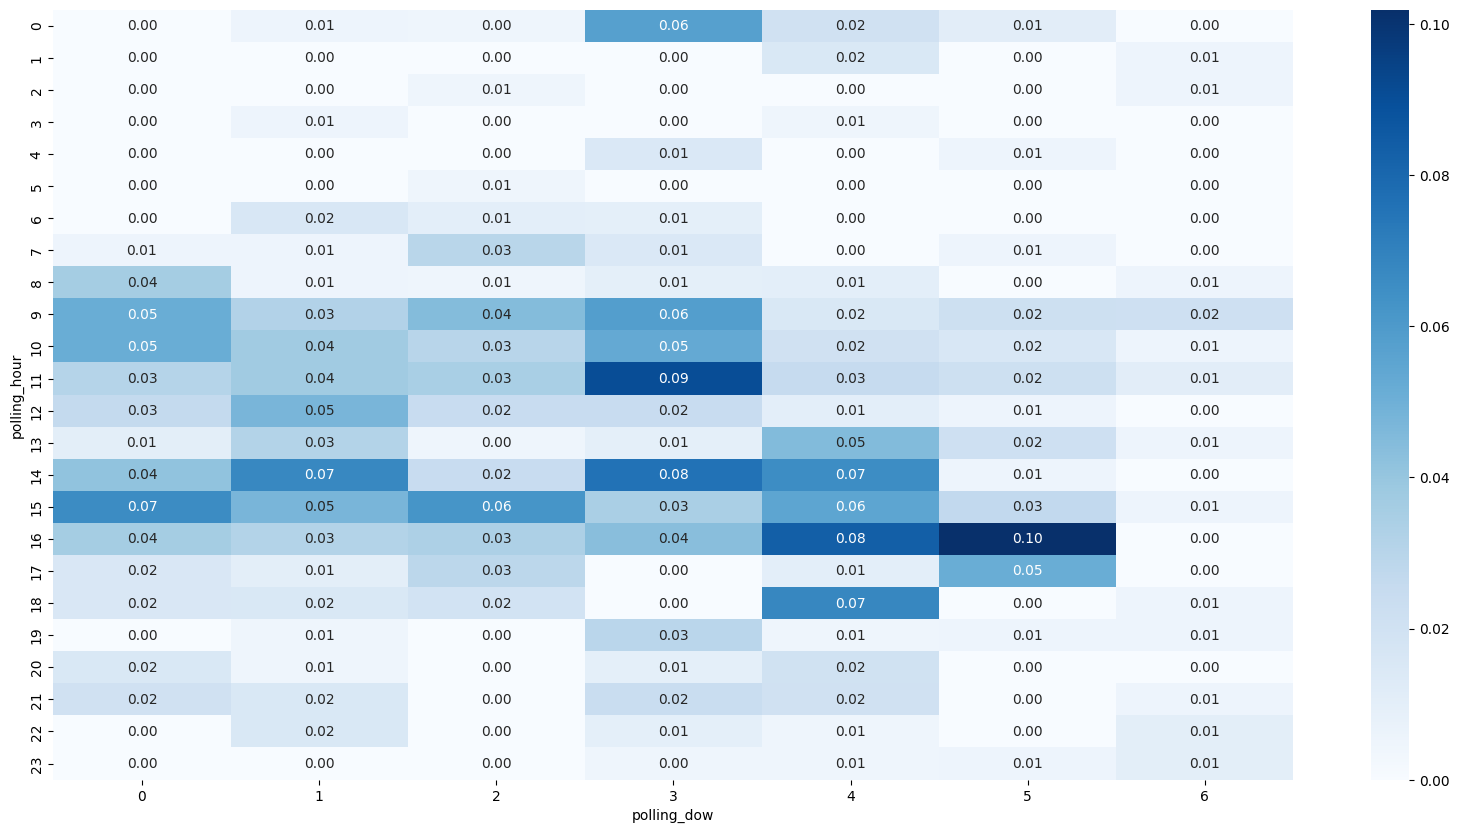

In [289]:
fig,ax = plt.subplots(figsize=(20,10))
sns.heatmap(pv,annot=True,fmt=".2f",cmap="Blues")

      username               cycle_start                 cycle_end  \
0       addity 2025-08-13 21:00:00+08:00 2025-08-28 11:36:00+08:00   
22959     matt 2025-08-12 01:21:00+08:00 2025-09-23 23:52:00+08:00   
23887      max 2025-09-24 00:00:00+08:00 2025-09-25 23:59:00+08:00   
25565    natar 2025-10-16 00:00:00+08:00 2025-10-17 23:59:00+08:00   
23902      mya 2025-10-29 16:15:00+08:00 2025-11-01 23:59:00+08:00   
27902     ryan 2025-11-01 21:30:00+08:00 2025-11-03 23:59:00+08:00   
31595   tomato 2025-11-26 11:00:00+08:00 2025-11-27 23:59:00+08:00   
26925     phuc 2025-12-30 16:00:00+08:00 2026-01-01 23:59:00+08:00   
26894  pakning 2026-01-20 17:00:00+08:00 2026-01-26 23:59:00+08:00   
996        ali 2026-02-06 10:00:00+08:00 2026-02-25 23:59:00+08:00   
9563     faith 2026-02-27 00:00:00+08:00 2026-03-09 23:59:00+08:00   

       cycle_duration  
0          350.600000  
22959     1030.516667  
23887       47.983333  
25565       47.983333  
23902       79.733333  
27902       50.

<Axes: ylabel='cycle_duration'>

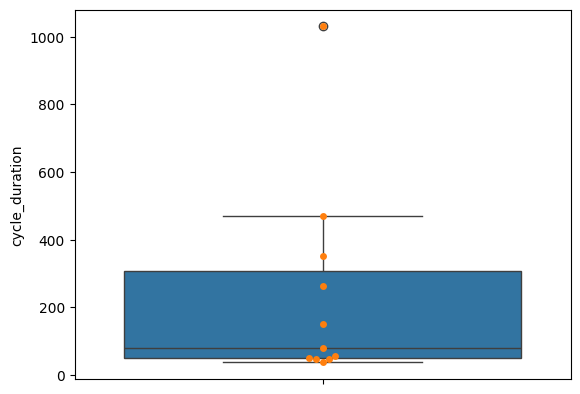

In [291]:
ot_customers = df.loc[df["is_one_team"]==1].sort_values("cycle_end").drop_duplicates(subset=["username"],keep="first")[["username","cycle_start","cycle_end"]]
ot_customers["cycle_duration"] = (ot_customers["cycle_end"] - ot_customers["cycle_start"]).dt.total_seconds()/3600
print(ot_customers)
sns.boxplot(data=ot_customers,y="cycle_duration")
sns.swarmplot(data=ot_customers,y="cycle_duration")

Overall base rate: 0.0165


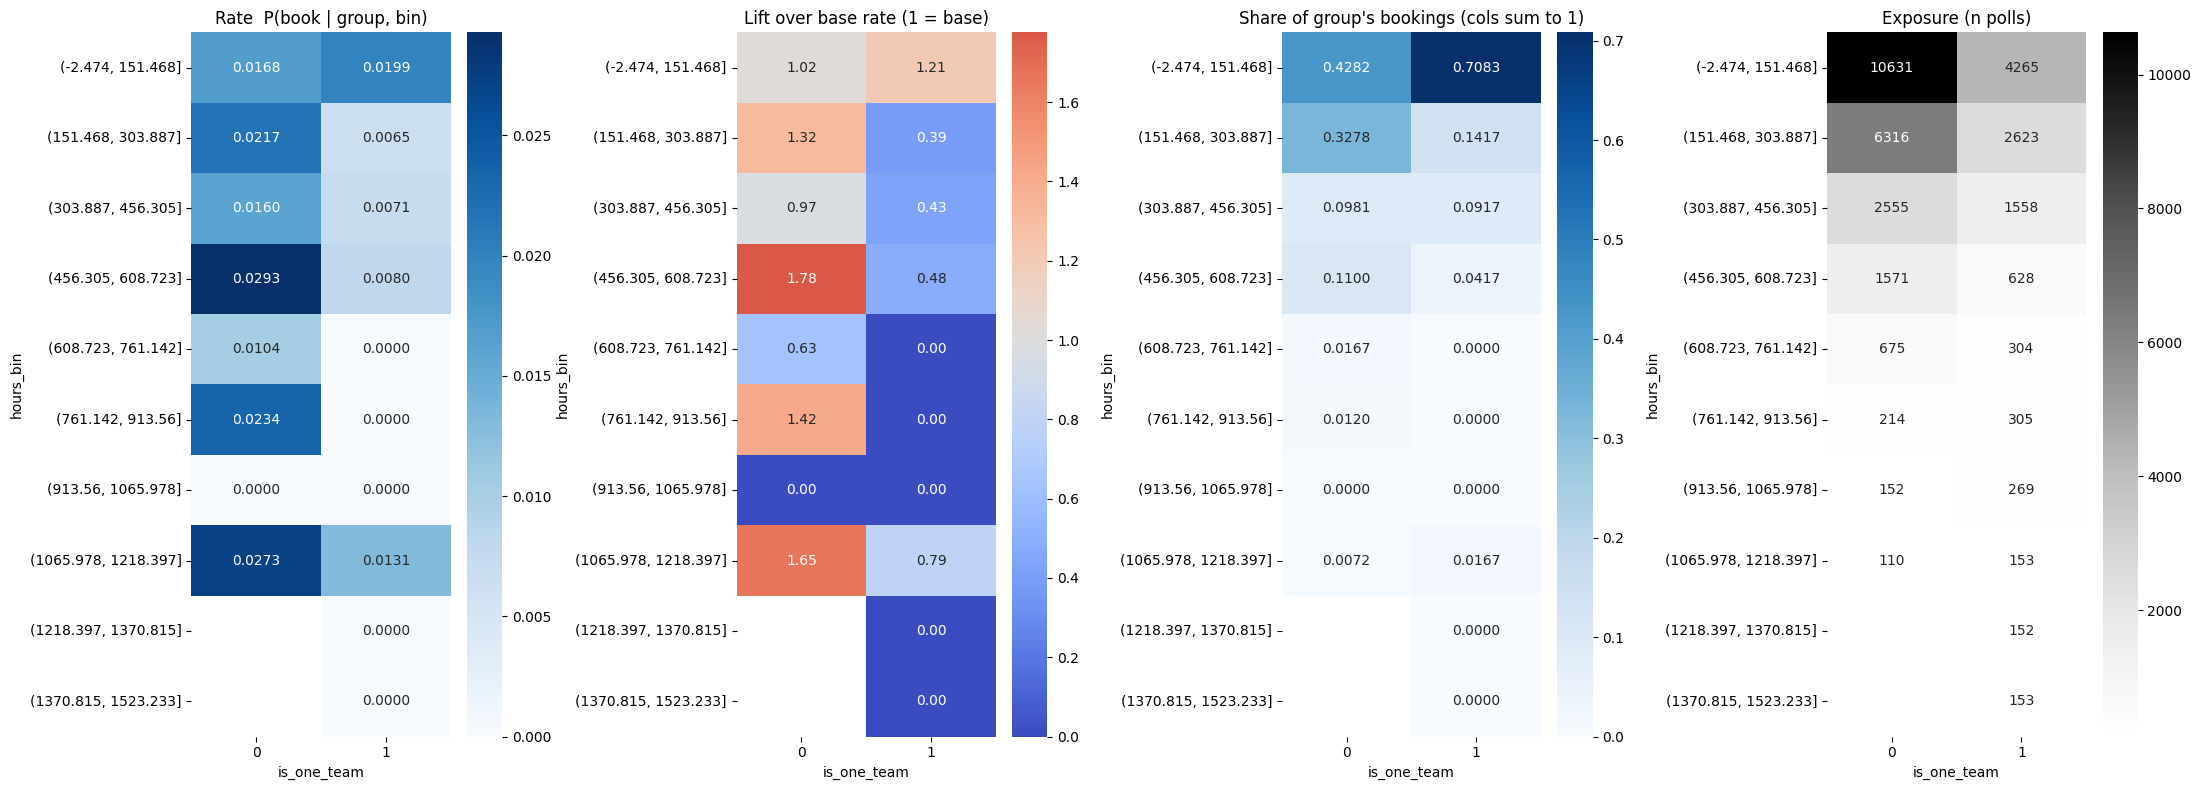

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

base_rate = df["has_booking"].mean()
print(f"Overall base rate: {base_rate:.4f}")

# one pass, all aggregates
g = (df.groupby(["is_one_team", "hours_bin"])["has_booking"]
       .agg(n_polls="count", n_bookings="sum", rate="mean")
       .reset_index())

# within-group totals for normalization
grp_bookings = df.groupby("is_one_team")["has_booking"].sum()

# share of THIS GROUP's bookings landing in this bin -> columns sum to ~1 -> tests concentration
g["share_of_group_bookings"] = g["n_bookings"] / g["is_one_team"].map(grp_bookings)
# multiplicative lift over base rate -> reads signal strength, not absolute smallness
g["lift"] = g["rate"] / base_rate

def pv(col):
    return pd.pivot(g, index="hours_bin", columns="is_one_team", values=col)

fig, axes = plt.subplots(1, 4, figsize=(22, 8))

sns.heatmap(pv("rate"), annot=True, fmt=".4f", cmap="Blues", ax=axes[0])
axes[0].set_title("Rate  P(book | group, bin)")

sns.heatmap(pv("lift"), annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title("Lift over base rate (1 = base)")

sns.heatmap(pv("share_of_group_bookings"), annot=True, fmt=".4f", cmap="Blues", ax=axes[2])
axes[2].set_title("Share of group's bookings (cols sum to 1)")

sns.heatmap(pv("n_polls"), annot=True, fmt=".0f", cmap="Greys", ax=axes[3])
axes[3].set_title("Exposure (n polls)")

plt.tight_layout()
plt.show()